In [1]:
import numpy as np
import matplotlib.pyplot as plt

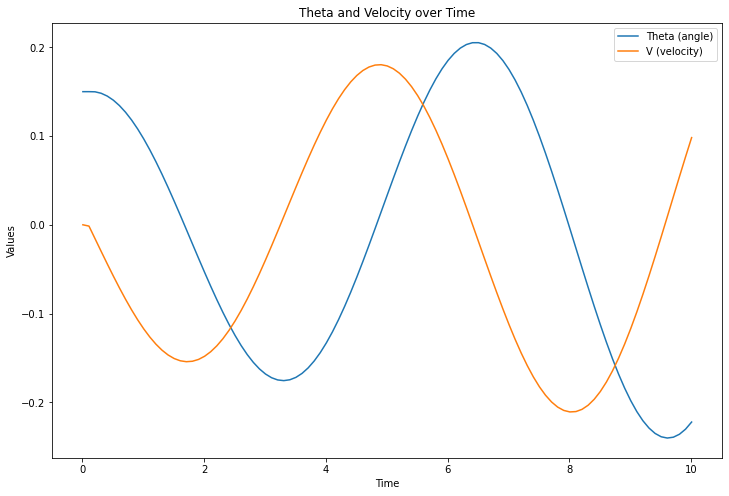

In [36]:
def RKF(t1, theta_0, v_0,h0, tol):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = [0]
    # n is the number of timesteps in t
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = []
    #same for velocities
    v = []
    
    e = []
    
    #Set the initial value of x and v
    
    g = 1
    l = 1
    
    a21 = 1/5
    a31 = 3/40
    a32 = 9/40
    a41 = 44/45
    a42 = -56/15
    a43 = 32/9
    a51 = 19372/6561
    a52 = -25360/2187
    a53 = 64448/6561
    a54 = -212/729
    a61 = 9017/3168
    a62 = -355/33
    a63 = 46732/5247
    a64 = 49/176
    a65 = -5103/18656
    
    b1 = 35/384
    b2 = 0
    b3 = 500/1113
    b4 = 125/192
    b5 = -2187/6784
    b6 = 11/84
    
    bx1 = 5179/57600
    bx2 = 0
    bx3 = 7571/16695
    bx4 = 393/640
    bx5 = -92097/339200
    bx6 = 187/2100
    bx7 = 1/40
    
    #define F(theta) for coupled equation 1
    def F(v):
        
        return v
    
    #Define G(v) for coupled equation 2
    def G(theta):
        
        return -g/l * np.sin(theta)
    
    h = h0
    thet = theta_0
    ve = v_0
    E = 0.5 * v_0**2 + g*l*(1-np.cos(theta_0))

    #Loop over the time values and calculate the derivatives
    while t[-1] < t1:
             
        t.append(t[-1]+h)
        theta.append(thet)
        v.append(ve)
        
        e.append(E)
        
        err = 2
        
        while err > 1:
        
            # Calculate the Runge - Kutta intermediate values
            f1 = h * F(v[-1])
            f2 = h * F(v[-1]+a21*f1)
            f3 = h * F(v[-1]+a31*f1+a32*f2)
            f4 = h * F(v[-1]+a41*f1+a42*f2+a43*f3)
            f5 = h * F(v[-1]+a51*f1+a52*f2+a53*f3+a54*f4)
            f6 = h * F(v[-1]+a61*f1+a62*f2+a63*f3+a64*f4+a65*f5)
            f7 = h * F(v[-1]+b1*f1+b2*f2+b3*f3+b4*f4+b5*f5+b6*f6)
            
            g1 = h * G(theta[-1])
            g2 = h * G(theta[-1]+a21*g1)
            g3 = h * G(theta[-1]+a31*g1+a32*g2)
            g4 = h * G(theta[-1]+a41*g1+a42*g2+a43*g3)
            g5 = h * G(theta[-1]+a51*g1+a52*g2+a53*g3+a54*g4)
            g6 = h * G(theta[-1]+a61*g1+a62*g2+a63*g3+a64*g4+a65*g5)
            g7 = h * G(theta[-1]+b1*g1+b2*g2+b3*g3+b4*g4+b5*g5+b6*g6)
            
            thet = theta[-1] + b1*f1 + b2*f2 + b3*f3 + b4*f4 + b5*f5 + b6*f6
            theta_star = theta[-1] + bx1*f1 + bx2*f2 + bx3*f3 + bx4*f4 + bx5*f5 + bx6*f6 + bx7*f7
            
            
            ve = v[-1] + b1*g1 + b2*g2 + b3*g3 + b4*g4 + b5*g5 + b6*g6
            v_star = v[-1] + bx1*g1 + bx2*g2 + bx3*g3 + bx4*g4 + bx5*g5 + bx6*g6 + bx7*g7
            
            delta1 = theta_star - thet
            delta2 = v_star - ve
            
            scale1 = tol + np.abs(np.max((thet,theta_star)))*tol
            scale2 = tol + np.abs(np.max((ve,v_star)))*tol
            
            err = np.sqrt(0.5*(delta1/scale1)**2 + 0.5*(delta2/scale2)**2)
            
            p = 0.9 * h * np.abs(1/err)**0.2
            
            if p < 10 * h and p > 5 * h:
            
                h = p
                
            elif p >= 10*h:
                h=h*10
                
            elif p<=h/5:
                h=h/5
                
            E = 0.5 * ve**2 + g*l*(1-np.cos(thet))
            
            #print("t = {0} : err = {1} : h = {2}".format(t[-1],err,h))
        
        
        
        
    return(t,theta,v,e) 

t1, theta_0, v_0, h0, tol = 10, 0.15, 0, 1e-2, 1e-6
t, theta, v, e = RKF(t1, theta_0, v_0, h0, tol)

plt.figure(figsize=(12,8))
plt.plot(t[1:], theta, label='Theta (angle)')
plt.plot(t[1:], v, label='V (velocity)')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Theta and Velocity over Time')
plt.legend()
plt.show()

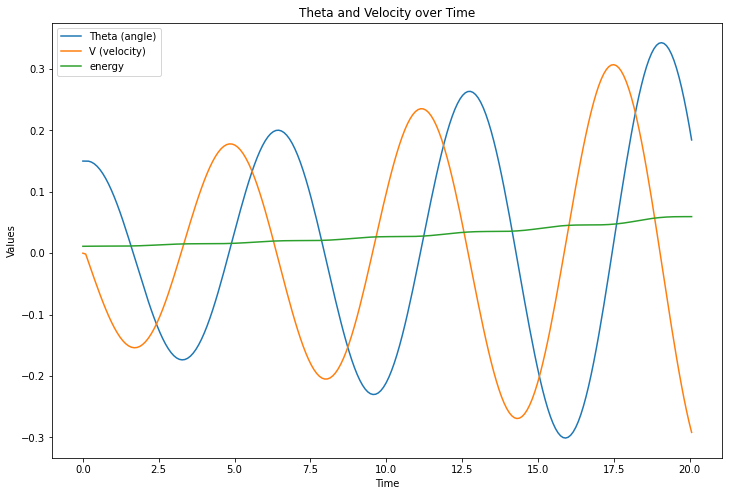

In [39]:
#Define the function
def RKF(t1, theta_0, v_0,h0, tol):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = [0]
    # n is the number of timesteps in t
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta = []
    #same for velocities
    v = []
    
    e = []
    
    #declare array to store acceleration at each point, I am considering acceleration 
    #because I want to see how the rate of change of position varies with rate of change of velocity, 
    # I have a hunch that the solution is breaking down because the velocity and position are at their 
    # max rates of change at opposite times, hence they are battling for control of the step size. 
    acceleration = []
    
    #Set the initial value of x and v
    
    g = 1
    l = 1
    
    a21 = 1/5
    a31 = 3/40
    a32 = 9/40
    a41 = 44/45
    a42 = -56/15
    a43 = 32/9
    a51 = 19372/6561
    a52 = -25360/2187
    a53 = 64448/6561
    a54 = -212/729
    a61 = 9017/3168
    a62 = -355/33
    a63 = 46732/5247
    a64 = 49/176
    a65 = -5103/18656
    
    b1 = 35/384
    b2 = 0
    b3 = 500/1113
    b4 = 125/192
    b5 = -2187/6784
    b6 = 11/84
    
    bx1 = 5179/57600
    bx2 = 0
    bx3 = 7571/16695
    bx4 = 393/640
    bx5 = -92097/339200
    bx6 = 187/2100
    bx7 = 1/40
    
    #define F(theta) for coupled equation 1
    def F(v):
        return v

    def G(theta):
        return -g / l * np.sin(theta)

    # Initialization
    t = [0]
    theta = [theta_0]
    v = [v_0]
    e = [0.5 * v_0**2 + g * l * (1 - np.cos(theta_0))]
    h = h0

    # Main loop
    while t[-1] < t1:
        
        # Compute intermediate steps        
        f1 = h * F(v[-1])
        f2 = h * F(v[-1]+a21*f1)
        f3 = h * F(v[-1]+a31*f1+a32*f2)
        f4 = h * F(v[-1]+a41*f1+a42*f2+a43*f3)
        f5 = h * F(v[-1]+a51*f1+a52*f2+a53*f3+a54*f4)
        f6 = h * F(v[-1]+a61*f1+a62*f2+a63*f3+a64*f4+a65*f5)
        f7 = h * F(v[-1]+b1*f1+b2*f2+b3*f3+b4*f4+b5*f5+b6*f6)
            
        g1 = h * G(theta[-1])
        g2 = h * G(theta[-1]+a21*g1)
        g3 = h * G(theta[-1]+a31*g1+a32*g2)
        g4 = h * G(theta[-1]+a41*g1+a42*g2+a43*g3)
        g5 = h * G(theta[-1]+a51*g1+a52*g2+a53*g3+a54*g4)
        g6 = h * G(theta[-1]+a61*g1+a62*g2+a63*g3+a64*g4+a65*g5)
        g7 = h * G(theta[-1]+b1*g1+b2*g2+b3*g3+b4*g4+b5*g5+b6*g6)

        # Update values using RKF method
        thet = theta[-1] + b1*f1 + b2*f2 + b3*f3 + b4*f4 + b5*f5 + b6*f6
        theta_star = theta[-1] + bx1*f1 + bx2*f2 + bx3*f3 + bx4*f4 + bx5*f5 + bx6*f6 + bx7*f7
        ve = v[-1] + b1*g1 + b2*g2 + b3*g3 + b4*g4 + b5*g5 + b6*g6
        v_star = v[-1] + bx1*g1 + bx2*g2 + bx3*g3 + bx4*g4 + bx5*g5 + bx6*g6 + bx7*g7

        # Error estimation
        delta1 = theta_star - thet
        delta2 = v_star - ve
        
        
        scale1 = tol + np.abs(np.max([thet, theta_star])) * tol
        scale2 = tol + np.abs(np.max([ve, v_star])) * tol
        
        
        err = np.sqrt(0.5 * (delta1/scale1)**2 + 0.5 * (delta2/scale2)**2)

        # Adaptive step size control
        p = 0.9 * h * np.abs(1 / err)**0.2 # making factor smaller than 0.9 would be cheating but does give more stable values
        
        if p < 10 * h and p > 0.1 * h: 
            h = p
            # print("p falls in bounds, nice.")

        elif p >= 10 * h:
            print(len(theta), h, err)
            break
            h = h * 5
            # print("p greater than 10h")

            
        elif p <= 0.1 * h:
            h = h * 0.1
            # print("p less than 0.1*h")

        # Energy calculation
        E = 0.5 * ve**2 + g * l * (1 - np.cos(thet))

        # Append at the end to meet condition
        # Updates the arrays with new values only if the error is within acceptable limits
        if err < 1:
            t.append(t[-1] + h)
            theta.append(thet)
            v.append(ve)
            e.append(E)
        #print(p)
        #print current step info
        # print(f"t = {t[-1]} : theta = {thet} : v = {ve} : err = {err} : h = {h}")
    return t, theta, v, e

# Example usage
t1, theta_0, v_0, h0, tol = 20, 0.15, 0, 1e-2, 1e-9 # really small errtol gives the best plots
t, theta, v, e = RKF(t1, theta_0, v_0, h0, tol)

plt.figure(figsize=(12,8))
plt.plot(t, theta, label='Theta (angle)')
plt.plot(t, v, label='V (velocity)')
plt.plot(t, e, label='energy')
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Theta and Velocity over Time')
#plt.axhline(y=0, linestyle='--')
plt.legend()
plt.show()

In [ ]:
# RKF 